# Linear Regression - From Scratch và `scikit-learn`


## Lý thuyết Linear Regression

**Linear Regression (Hồi quy tuyến tính)** là thuật toán học máy giám sát dùng để dự đoán kết quả dạng số liên tục dựa trên các biến độc lập. Cụ thể:

### 1. Ý tưởng cốt lõi
* Tìm mối quan hệ **tuyến tính** giữa biến độc lập (features) $X$ và biến phụ thuộc (target) $y$.
* Phương trình giả định: $\hat{y} = Xw + b$ (với $w$ là weights/trọng số và $b$ là bias).
* Mục tiêu là tìm bộ tham số $(w, b)$ làm giảm tối đa hàm mất mát Mean Squared Error (MSE):
  $$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

### 2. Các bước thực hiện

* **Bước 1 (Khởi tạo):** Khởi tạo weights $w = 0$ và bias $b = 0$.
* **Bước 2 (Forward pass):** Tính dự đoán $\hat{y} = Xw + b$.
* **Bước 3 (Tính gradient):** Tính đạo hàm MSE theo $w$ và $b$:
  * $\frac{\partial MSE}{\partial w} = \frac{2}{N} X^T (\hat{y} - y)$
  * $\frac{\partial MSE}{\partial b} = \frac{2}{N} \sum (\hat{y} - y)$
* **Bước 4 (Cập nhật tham số):** Gradient Descent với learning rate $\alpha$:
  * $w \leftarrow w - \alpha \frac{\partial MSE}{\partial w}$
  * $b \leftarrow b - \alpha \frac{\partial MSE}{\partial b}$
* **Bước 5 (Lặp lại):** Lặp lại bước 2–4 cho đến khi hội tụ hoặc đủ số epoch.

### 3. Ưu điểm so với các phương pháp phức tạp hơn
* **Đơn giản, dễ giải thích** — hệ số $w$ phản ánh trực tiếp ảnh hưởng của từng feature.
* **Tốc độ nhanh** — giải tích bằng Normal Equation (OLS) cho nghiệm tối ưu tức thì: $w = (X^T X)^{-1} X^T y$.
* **Nền tảng** cho các mô hình phức tạp hơn như Ridge, Lasso, Elastic Net.


## Triển khai `LinearRegression` không dùng thư viện


### Import thư viện và load dữ liệu


In [39]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sklearn.linear_model
import os, sys, time

sys.path.append(os.path.abspath(os.path.join('..')))
from practice_2.utils.custom_hyperparameter_tuning import CustomGridSearchCV
from practice_2.utils.custom_cv import CustomKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from general_utils.model_manager import save_model_package

In [38]:
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test  = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train_log.pkl')
y_test  = joblib.load('./data/ready_for_train/y_test_log.pkl')

print('Training dataset shape:')
print(f'X: {X_train.shape}')
print(f'y: {y_train.shape}')

print('Testing dataset shape:')
print(f'X: {X_test.shape}')
print(f'y: {y_test.shape}')

Training dataset shape:
X: (79565, 13)
y: (79565,)
Testing dataset shape:
X: (19892, 13)
y: (19892,)


### Triển khai Linear Regression không dùng `sklearn`


In [26]:
class LinearRegressionScratch:
    """Mô hình Linear Regression tự triển khai sử dụng Gradient Descent."""

    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000):
        self.learning_rate = learning_rate
        self.epochs        = epochs
        self.weights       = None
        self.bias          = None
        self.loss_history  = []

    def get_params(self, deep=True):
        return {'learning_rate': self.learning_rate, 'epochs': self.epochs}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        # Bước 1: Khởi tạo weights = 0, bias = 0
        self.weights      = np.zeros(n_features)
        self.bias         = 0.0
        self.loss_history = []

        for _ in range(self.epochs):
            # Bước 2: Forward pass
            y_pred = np.dot(X, self.weights) + self.bias

            # Bước 3: Tính gradient
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Bước 4: Cập nhật tham số (Gradient Descent)
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            # Bước 5: Ghi lại loss
            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X) -> np.ndarray:
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

### Kiểm tra nhanh mô hình Linear Regression From Scratch


In [27]:
y_train_original = np.expm1(y_train)
y_test_original  = np.expm1(y_test)

quick_lr = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

start = time.time()
quick_lr.fit(X_train, y_train.values)
train_time = time.time() - start

In [28]:
quick_pred = np.expm1(quick_lr.predict(X_test))

In [29]:
r2   = r2_score(y_test_original, quick_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, quick_pred))
mae  = mean_absolute_error(y_test_original, quick_pred)
mape = mean_absolute_percentage_error(y_test_original, quick_pred) * 100 # Nhân 100 để lấy định dạng %

print(f'Quick test (1000 epochs) - Train time: {train_time:.1f}s')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f"MAPE : {mape:.2f} %")

Quick test (1000 epochs) - Train time: 1.4s
R²   : 0.1299
RMSE : 885.80
MAE  : 406.04
MAPE : 77.58 %


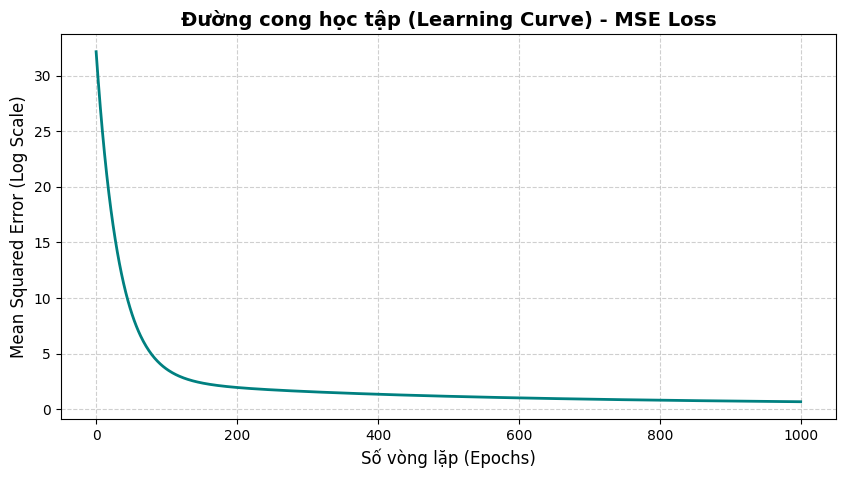

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(quick_lr.epochs), quick_lr.loss_history, color='teal', linewidth=2)
plt.title('Learning Curve - MSE Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Log Scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Dùng thư viện `sklearn` để triển khai `LinearRegression`


In [30]:
sklearn_lr = LinearRegression()

start = time.time()
sklearn_lr.fit(X_train, y_train)
train_time_sklearn = time.time() - start

sklearn_pred = np.expm1(sklearn_lr.predict(X_test))

r2_sk   = r2_score(y_test_original, sklearn_pred)
rmse_sk = np.sqrt(mean_squared_error(y_test_original, sklearn_pred))
mae_sk  = mean_absolute_error(y_test_original, sklearn_pred)
mape_sk = mean_absolute_percentage_error(y_test_original, sklearn_pred) * 100
print(f'sklearn LinearRegression - Train time: {train_time_sklearn:.1f}s')
print(f'R²   : {r2_sk:.4f}')
print(f'RMSE : {rmse_sk:.2f}')
print(f'MAE  : {mae_sk:.2f}')
print(f"MAPE : {mape_sk:.2f} %")

sklearn LinearRegression - Train time: 0.0s
R²   : 0.7059
RMSE : 514.97
MAE  : 288.89
MAPE : 57.05 %


## Hyperparameter Tuning

Để tối ưu hóa Linear Regression, Grid Search kết hợp với **5-fold Cross Validation** được sử dụng nhằm tìm ra bộ hyperparameters phù hợp nhất.

Parameter grid được sử dụng:

```python
lr_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'epochs'       : [500, 1000, 2000],
}
```

Trong đó:
* `learning_rate` — tốc độ học của Gradient Descent.
* `epochs` — số vòng lặp huấn luyện.

Mô hình được đánh giá trên **giá gốc** (`price`) sau khi `inverse transform` qua `np.expm1()`.


In [31]:
lr_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'epochs'       : [500, 1000, 2000],
}

### Grid Search dùng Neg RMSE


In [20]:
cv = CustomKFold(n_splits=5, shuffle=True, random_state=42)
scratch_lr = LinearRegressionScratch()

lr_grid_search = CustomGridSearchCV(
    estimator=scratch_lr,
    param_grid=lr_grid,
    cv=cv,
    scoring='neg_rmse'
)

lr_grid_search.fit(X_train, y_train.values)

Bắt đầu GridSearchCV: 9 tổ hợp tham số, 5 folds.
[1/9] Params: {'learning_rate': 0.001, 'epochs': 500} --> neg_rmse: -2.9644
[2/9] Params: {'learning_rate': 0.001, 'epochs': 1000} --> neg_rmse: -1.9070
[3/9] Params: {'learning_rate': 0.001, 'epochs': 2000} --> neg_rmse: -1.3996
[4/9] Params: {'learning_rate': 0.01, 'epochs': 500} --> neg_rmse: -1.0789
[5/9] Params: {'learning_rate': 0.01, 'epochs': 1000} --> neg_rmse: -0.8226
[6/9] Params: {'learning_rate': 0.01, 'epochs': 2000} --> neg_rmse: -0.6384
[7/9] Params: {'learning_rate': 0.1, 'epochs': 500} --> neg_rmse: -0.5603
[8/9] Params: {'learning_rate': 0.1, 'epochs': 1000} --> neg_rmse: -0.5566
[9/9] Params: {'learning_rate': 0.1, 'epochs': 2000} --> neg_rmse: -0.5566

-> Tham số TỐT NHẤT: {'learning_rate': 0.1, 'epochs': 2000}
-> Điểm neg_rmse TỐT NHẤT: -0.5566


### Grid Search dùng R²


In [32]:
cv = CustomKFold(n_splits=5, shuffle=True, random_state=42)
scratch_lr = LinearRegressionScratch()

lr_grid_search_r2 = CustomGridSearchCV(
    estimator=scratch_lr,
    param_grid=lr_grid,
    cv=cv,
    scoring='r2'
)

lr_grid_search_r2.fit(X_train, y_train.values)

Bắt đầu GridSearchCV: 9 tổ hợp tham số, 5 folds.
[1/9] Params: {'learning_rate': 0.001, 'epochs': 500} --> r2: -1.7889
[2/9] Params: {'learning_rate': 0.001, 'epochs': 1000} --> r2: -0.1541
[3/9] Params: {'learning_rate': 0.001, 'epochs': 2000} --> r2: 0.3784
[4/9] Params: {'learning_rate': 0.01, 'epochs': 500} --> r2: 0.6306
[5/9] Params: {'learning_rate': 0.01, 'epochs': 1000} --> r2: 0.7853
[6/9] Params: {'learning_rate': 0.01, 'epochs': 2000} --> r2: 0.8707
[7/9] Params: {'learning_rate': 0.1, 'epochs': 500} --> r2: 0.9004
[8/9] Params: {'learning_rate': 0.1, 'epochs': 1000} --> r2: 0.9017
[9/9] Params: {'learning_rate': 0.1, 'epochs': 2000} --> r2: 0.9017

-> Tham số TỐT NHẤT: {'learning_rate': 0.1, 'epochs': 2000}
-> Điểm r2 TỐT NHẤT: 0.9017


In [34]:
best_params = lr_grid_search_r2.best_params_
print('Best params:', best_params)

# ── From Scratch với best params ──────────────────────
scratch_best = lr_grid_search_r2.best_estimator_

start = time.time()
scratch_best.fit(X_train, y_train.values)
train_time_scratch = time.time() - start

scratch_pred = np.expm1(scratch_best.predict(X_test))

mae_scratch  = mean_absolute_error(y_test_original, scratch_pred)
rmse_scratch = np.sqrt(mean_squared_error(y_test_original, scratch_pred))
r2_scratch   = r2_score(y_test_original, scratch_pred)
mape_scratch = mean_absolute_percentage_error(y_test_original, scratch_pred) * 100

# ── sklearn với cùng cách tiếp cận (train trên y_log) ─ đánh giá trên y_test gốc
start = time.time()
sklearn_best = LinearRegression()
sklearn_best.fit(X_train, y_train)
train_time_sklearn = time.time() - start

sklearn_pred_best = np.expm1(sklearn_best.predict(X_test))

mae_sklearn  = mean_absolute_error(y_test_original, sklearn_pred_best)
rmse_sklearn = np.sqrt(mean_squared_error(y_test_original, sklearn_pred_best))
r2_sklearn   = r2_score(y_test_original, sklearn_pred_best)
mape_sklearn = mean_absolute_percentage_error(y_test_original, sklearn_pred_best) * 100
# ── Bảng so sánh ─────────────────────────────────────
print('\n' + '='*60)
print(f"{'Metric':<15} {'From Scratch':>20} {'sklearn':>20}")
print('='*60)
print(f"{'R²':<15} {r2_scratch:>20.4f} {r2_sklearn:>20.4f}")
print(f"{'RMSE':<15} {rmse_scratch:>20.2f} {rmse_sklearn:>20.2f}")
print(f"{'MAE':<15} {mae_scratch:>20.2f} {mae_sklearn:>20.2f}")
print(f"{'MAPE':<15} {mape_scratch:>20.2f} {mape_sklearn:>20.2f}")
print(f"{'Train Time (s)':<15} {train_time_scratch:>20.1f} {train_time_sklearn:>20.1f}")
print('='*60)

# So sánh sai lệch dự đoán
max_diff = np.max(np.abs(scratch_pred - sklearn_pred_best))
print(f'\nSai lệch dự đoán tối đa giữa 2 mô hình: {max_diff:.4f}')

Best params: {'learning_rate': 0.1, 'epochs': 2000}

Metric                  From Scratch              sklearn
R²                            0.7059               0.7059
RMSE                          514.99               514.97
MAE                           288.89               288.89
MAPE                           57.05                57.05
Train Time (s)                   2.6                  0.0

Sai lệch dự đoán tối đa giữa 2 mô hình: 0.3314


## So sánh y gốc vs y log-transformed

Linear Regression rất nhạy cảm với phân phối của target. Dữ liệu giá (`price`) có phân phối lệch phải mạnh nên việc áp dụng log-transformation có thể cải thiện đáng kể hiệu năng mô hình.


In [24]:
import matplotlib.pyplot as plt

# ── From Scratch: y GỐC và y LOG ────────────────────────────────────
sc_orig = LinearRegressionScratch(learning_rate=0.1, epochs=2000)
sc_orig.fit(X_train, y_train_original.values)
pred_sc_orig = sc_orig.predict(X_test)

sc_log = LinearRegressionScratch(learning_rate=0.1, epochs=2000)
sc_log.fit(X_train, y_train.values)
pred_sc_log = np.expm1(sc_log.predict(X_test))

# ── sklearn LinearRegression: y GỐC và y LOG ────────────────────────
sk_orig = LinearRegression()
sk_orig.fit(X_train, y_train_original)
pred_sk_orig = sk_orig.predict(X_test)

sk_log = LinearRegression()
sk_log.fit(X_train, y_train)
pred_sk_log = np.expm1(sk_log.predict(X_test))

# ── Bảng so sánh tổng hợp (đánh giá trên thang đo giá GỐC) ─────────
W = 18
print(f"{'Metric':<15} {'Scratch/y_gốc':>{W}} {'Scratch/y_log':>{W}} {'sklearn/y_gốc':>{W}} {'sklearn/y_log':>{W}}")
print('-' * (15 + W*4 + 3))
for label, pred in [('R²', None), ('RMSE', None), ('MAE', None)]:
    v1 = r2_score(y_test_original, pred_sc_orig)    if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sc_orig)) if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sc_orig))
    v2 = r2_score(y_test_original, pred_sc_log)     if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sc_log))  if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sc_log))
    v3 = r2_score(y_test_original, pred_sk_orig)    if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sk_orig)) if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sk_orig))
    v4 = r2_score(y_test_original, pred_sk_log)     if label == 'R²' else (np.sqrt(mean_squared_error(y_test_original, pred_sk_log))  if label == 'RMSE' else mean_absolute_error(y_test_original, pred_sk_log))
    fmt = '.4f' if label == 'R²' else '.2f'
    print(f"{label:<15} {v1:>{W}{fmt}} {v2:>{W}{fmt}} {v3:>{W}{fmt}} {v4:>{W}{fmt}}")

Metric               Scratch/y_gốc      Scratch/y_log      sklearn/y_gốc      sklearn/y_log
------------------------------------------------------------------------------------------
R²                          0.7323             0.7059             0.7323             0.7059
RMSE                        491.31             514.99             491.31             514.97
MAE                         271.21             288.89             271.21             288.89


## Kết luận

### Hướng triển khai Linear Regression
- **From Scratch:** Triển khai thuật toán hồi quy tuyến tính bằng phương pháp **Gradient Descent**, cập nhật tham số weights và bias tuần tự dựa trên đạo hàm của MSE loss. Cách này giúp hiểu rõ cơ chế **tối ưu hóa** và **vai trò của learning rate** trong quá trình học.
- **Sử dụng `LinearRegression`** có sẵn từ `sklearn.linear_model`, giải trực tiếp nghiệm tối ưu thông qua phương trình Normal Equation (OLS), mang lại độ chính xác cao và tốc độ hội tụ tức thời.

### So sánh hiệu năng giữa hai cách triển khai
Kết quả metric (R², RMSE, MAE) giữa hai phiên bản khi cùng train trên y_log gần như tương đương nhau, với sai lệch nhỏ do Gradient Descent bị giới hạn bởi learning rate và số epochs. Phiên bản `sklearn` nhanh hơn đáng kể nhờ nghiệm giải tính (OLS).

### Ảnh hưởng của log-transformation lên target
Khi train với **y_log** (`log1p(price)`) và inverse transform dự đoán về giá gốc qua `np.expm1()`, mô hình đạt hiệu năng tốt hơn đáng kể so với train trực tiếp trên **y gốc**, vì log-transform giúp ổn định phương sai và đưa phân phối target về dạng gần chuẩn hơn.

### Hướng giải quyết tiếp theo
Để cải thiện hiệu năng dự báo, phương án tiếp theo là áp dụng các mô hình phi tuyến như **Decision Tree Regressor**, **Random Forest Regressor** hoặc các thuật toán Boosting để khai thác các tương tác đặc trưng phức tạp hơn trong dữ liệu.


## Lưu model


In [ ]:
metrics_LR_regression = {
    'R2': r2_scratch,
    'MAE': mae_scratch,
    'RMSE': rmse_scratch,
    'MAPE': mape_scratch
}

save_model_package(
    model=scratch_best,
    model_name="linear_regression_scratch",
    best_params=best_params,
    metrics=metrics_LR_regression,
    save_dir='./models'
)

'models\\linear_regression_scratch.pkl'